# Smart Contract Vulnerability Detection: Data Preprocessing

This notebook handles the end-to-end preprocessing pipeline for the SmartBug dataset. The goal is to prepare Solidity source code for training with a Transformer model (CodeBERT), specifically focusing on line-level vulnerability localization.

Dataset from: https://www.kaggle.com/datasets/tranduongminhdai/smartbug-dataset/data

Solidity preprocessing code adapted from : https://www.kaggle.com/code/mestaysserasma/ai-driven-smart-contract-vulnerability-detection

### Key Steps:
1. **Data Loading**: Importing the raw dataset from Google Drive.
2. **Sampling**: Addressing severe class imbalance (94% vulnerable vs 6% safe).
3. **Cleaning**: Sanitizing Solidity code while preserving line numbers.
4. **Chunking**: Splitting long contracts into 512-token segments with a sliding window.
5. **Label Alignment**: Mapping global vulnerability line numbers to specific code chunks.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data Acquisition & Initial Loading
Mounting Drive and loading the master CSV containing contract addresses, source code, and expert-labeled vulnerability lines.

In [2]:
# Run once:
#import os
## Change this to the folder in your Drive where you saved kaggle.json

#os.environ['KAGGLE_CONFIG_DIR'] = "/content/drive/MyDrive/Kaggle"
#!mkdir -p "/content/drive/My Drive/CPSC440_project/data/smartbug_data"

## Download dataset to drive
#!kaggle datasets download -d tranduongminhdai/smartbug-dataset -p "/content/drive/My Drive/CPSC440_project/data/smartbug_data" --unzip

In [3]:
import pandas as pd

csv_path = "/content/drive/My Drive/CPSC440_project/data/smartbug_data/smartbugs_final_ver.csv"
df = pd.read_csv(csv_path)

In [4]:
df

,Unnamed: 0,address,tools,lines,nb_vulnerabilities,source_code,labels
0,0,0x8d12a197cb00d4747a1fe03395095ce2a5cc6819,"{'mythril': {'vulnerabilities': {}, 'categorie...","[32, 229, 38, 136, 268, 45, 51, 254, 56, 28, 2...",15.0,pragma solidity ^0.4.9;\n\ncontract SafeMath {...,unknow
1,1,0x2a0c0dbecc7e4d658f48e01e3fa353f44050c208,{'mythril': {'vulnerabilities': {'Unchecked CA...,"[163, 36, 101, 133, 110, 145, 122, 127]",10.0,pragma solidity ^0.4.16;\n\ncontract Token {\n...,reentrancy
2,2,0x174bfa6600bf90c885c7c01c7031389ed1461ab9,"{'mythril': {'vulnerabilities': {}, 'categorie...",[],0.0,pragma solidity >=0.4.22 <0.6.0;\n\ncontract o...,clean
3,3,0x06012c8cf97bead5deae237070f9587f8e7a266d,{'mythril': {'vulnerabilities': {'Unchecked CA...,"[769, 1414, 1287, 1686, 1175, 1048, 1817, 924,...",82.0,pragma solidity ^0.4.11;\n\n\n/**\n * @title O...,arithmetic
4,4,0x86fa049857e0209aa7d9e616f7eb3b3b78ecfdb0,"{'mythril': {'vulnerabilities': {}, 'categorie...",[115],1.0,contract DSNote {\n event LogNote(\n ...,arithmetic
...,...,...,...,...,...,...,...
47326,47446,0x000000eade0fe9269d0412a6055b6f3c5d968488,{'mythril': {'vulnerabilities': {'Message call...,"[47, 49, 51, 52, 54, 56]",6.0,pragma solidity ^0.4.23;\n\n// File: contracts...,reentrancy
47327,47447,0x000000d4e883e304c7f9574ebeecf238eb55a40f,"{'mythril': {'vulnerabilities': {}, 'categorie...",[24],1.0,pragma solidity ^0.4.24;\n\ninterface TokenRec...,arithmetic
47328,47448,0x000000961d1ac83a67d0ce61612b36f18c10c9b7,"{'mythril': {'vulnerabilities': {}, 'categorie...",[26],1.0,pragma solidity ^0.4.24;\n\ninterface TokenRec...,arithmetic
47329,47449,0x00000000e82eb0431756271f0d00cfb143685e7b,"{'mythril': {'vulnerabilities': {}, 'categorie...","[4069, 4029]",2.0,pragma solidity 0.5.6;\n\n\n/**\n * @title Met...,access_control


In [5]:
df.shape

(47331, 7)

In [6]:
df["labels"].value_counts()

,count
labels,
arithmetic,26645
reentrancy,5225
unknow,4508
front_running,3251
denial_service,2875
clean,2742
unchecked_low_calls,1131
access_control,591
time_manipulation,363


In [7]:
shortest_contract_index = df['source_code'].apply(len).idxmin()
shortest_contract = df.loc[shortest_contract_index]
shortest_contract['source_code']
shortest_contract

,43569
Unnamed: 0,43674
address,0x7222af88c86620651a5594204d1f5305b1a5671f
tools,"{'mythril': {'vulnerabilities': {}, 'categorie..."
lines,[]
nb_vulnerabilities,0.0
source_code,contract Eater{\n\tfunction(){\n\t\t\n\t}\n}
labels,clean


In [8]:
df["is_vulnerable"] = df['nb_vulnerabilities'] > 0

In [9]:
df["is_vulnerable"].value_counts()

,count
is_vulnerable,
True,44589
False,2742


## 2. Strategic Downsampling
The dataset is heavily skewed toward vulnerable contracts. We use **Stratified Sampling** to reduce the number of vulnerable samples to 12k while maintaining the distribution of specific vulnerability types (e.g., reentrancy, arithmetic), ensuring the model sees enough 'Clean' examples.

Because there is a serious class imbalance between the vulnerable vs safe smart contracts, we chose to downsample the vulenrable contracts through stratified sampling to 12K samples.

In [10]:
import ast
def has_valid_vuln_line(row):
    if not row["is_vulnerable"]:
        return True

    raw = row["lines"]

    if isinstance(raw, str):
        raw = ast.literal_eval(raw)

    if raw and isinstance(raw[0], list):
        raw = [x for sub in raw for x in sub]

    if not raw:
        return False

    source_len = len(str(row["source_code"]).split("\n"))

    # keep if ANY label is plausible
    for v in raw:
        if isinstance(v, (int, float)):
            if 0 <= int(v) < source_len:
                return True
            if 1 <= int(v) <= source_len:
                return True

    return False


df = df[df.apply(has_valid_vuln_line, axis=1)].copy()

In [11]:
df_vulnerable = df[df['is_vulnerable'] == True]
df_safe = df[df['is_vulnerable'] == False]

target_vuln_size = 12_000
df_vulnerable_sampled = df_vulnerable.groupby('labels', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), int(target_vuln_size * (len(x)/len(df_vulnerable)))), random_state=32)
)

# Combine back with all your clean samples
df_final_train = pd.concat([df_vulnerable_sampled, df_safe]).sample(frac=1, random_state=32).reset_index(drop=True)

/tmp/ipykernel_70561/3008011757.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_vulnerable_sampled = df_vulnerable.groupby('labels', group_keys=False).apply(


In [12]:
# get rid of the ambiguous vulnerability smart contracts:
df_clean = df_final_train[df_final_train['labels'] != 'unknow'].copy()
challenge_eval_df = df_final_train[df_final_train['labels'] == 'unknow'].copy()

In [13]:
print(df_clean.shape)
print(challenge_eval_df.shape)

(13528, 8)
(1210, 8)


In [14]:
df_clean["labels"].value_counts()

,count
labels,
arithmetic,7187
clean,2742
reentrancy,1408
front_running,870
denial_service,775
unchecked_low_calls,305
access_control,144
time_manipulation,97


/tmp/ipykernel_70561/3738891875.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


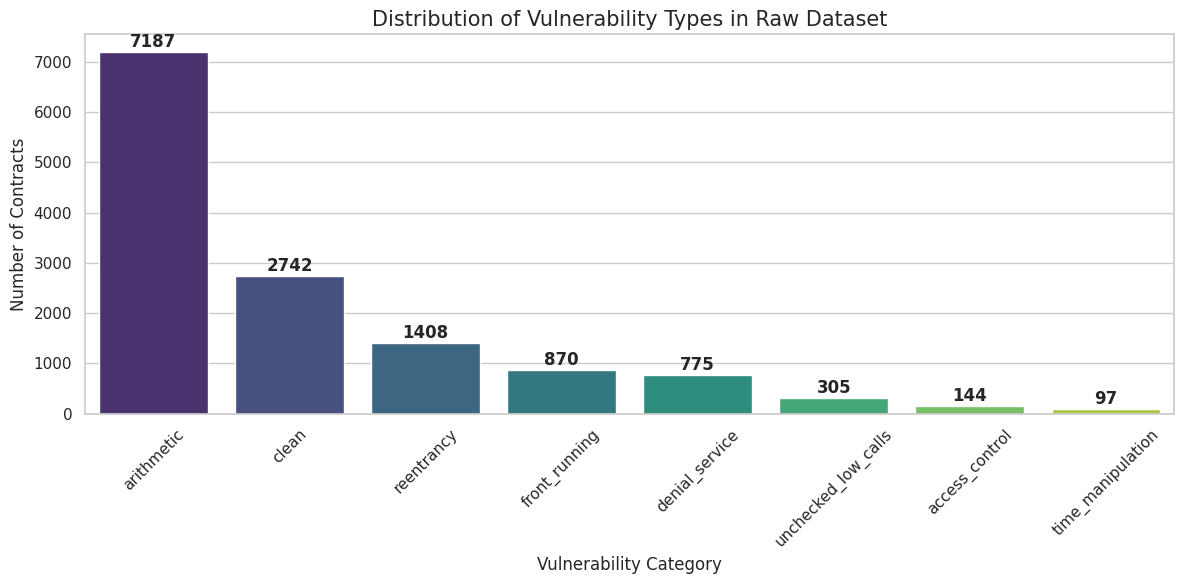

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for academic report
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Use the value counts from your df_clean
label_counts = df_clean['labels'].value_counts()

sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")

plt.title('Distribution of Vulnerability Types in Raw Dataset', fontsize=15)
plt.xlabel('Vulnerability Category', fontsize=12)
plt.ylabel('Number of Contracts', fontsize=12)
plt.xticks(rotation=45)

# Add value labels on top of bars
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=300)
plt.show()

In [16]:
df_clean['labels'].isnull().sum()

np.int64(0)

In [17]:
import re
# Keywords and known non-user-defined functions of Solidity
keywords = frozenset({
    # Data Types
    'bool', 'int', 'uint', 'string', 'bytes', 'enum', 'struct', 'mapping', 'bytes4', 'bytes32',

    # keywords
    'pragma', 'solidity', 'contract', 'library', 'interface', 'function', 'modifier', 'event',
    'if', 'else', 'while', 'for', 'do', 'break', 'continue', 'return',
    'import', 'using', 'as', 'assembly', 'emit', 'throw', 'revert', 'assert', 'require',
    'public', 'private', 'internal', 'external', 'view', 'pure', 'payable', 'constant',
    'memory', 'storage', 'calldata', 'immutable', 'override', 'virtual', 'anonymous',

    # Ethereum specific
    'msg', 'sender', 'value', 'block', 'timestamp', 'gas', 'this', 'super',

    # Solidity concepts
    'payable', 'constructor', 'indexed', 'case', 'catch', 'const', 'default',
    'float', 'long', 'noReentrancy', 'super', 'or', 'protected', 'noReentrancy',
    'returns', 'event', 'emit', 'export', 'extern', 'false', 'throw', 'true', 'try',
    'union', 'NULL', 'notConfirmed', 'onlyOwner', 'onlyGovernor', 'onlyCommittee',
    'onlyAdmin', 'onlyPlayers', 'ownerExists', 'onlyManager', 'onlyHuman', 'only_owner',
    'onlyCongressMembers', 'preventReentry', 'noEther', 'onlyMembers', 'onlyProxyOwner',
    'confirmed', 'notExecuted', 'assert', 'switch', 'preventReentry',
    'return', 'returns', 'constructor', 'indexed', 'pragma', 'solidity', 'contract', 'library',
    'interface', 'function', 'modifier', 'event', 'if', 'else', 'while', 'for', 'do', 'break',
    'continue', 'return', 'import', 'using', 'as', 'assembly', 'emit', 'throw', 'revert', 'assert',
    'require', 'public', 'private', 'internal', 'external', 'view', 'pure', 'payable', 'constant',
    'memory', 'storage', 'calldata', 'immutable', 'override', 'virtual', 'anonymous',

    # built in fns
    'selfdestruct', 'delegatecall', 'call', 'callcode', 'staticcall', 'create', 'create2',
    'keccak256', 'sha256', 'ripemd160', 'ecrecover', 'addmod', 'mulmod', 'balance', 'extcodesize',
    'extcodecopy', 'codesize', 'codecopy', 'gasleft', 'log0', 'log1', 'log2', 'log3', 'log4',

    # arithmetic + logic
    'add', 'sub', 'mul', 'div', 'mod', 'exp', 'iszero', 'lt', 'gt', 'eq', 'ne', 'and', 'or', 'not', 'xor',

    # state change
    'send', 'transfer', 'approve', 'transferFrom', 'mint', 'burn', 'mintTo', 'burnFrom', 'balanceOf',
    'owner', 'onlyOwner', 'isOwner', 'Transfer', 'Transaction',

    # others,,,
    'switch', 'pure', 'selfdestruct', 'view', 'this', 'union', 'constant', 'mapping'
})


main_set = frozenset({'function', 'constructor', 'modifier', 'contract'})
main_args = frozenset({'argc', 'argv'})

def remove_version(contract_text):
    return re.sub(r'pragma solidity\s+\^?\d+\.\d+\.\d+;', '', contract_text)

def remove_comments_and_non_ascii(contract):
    contract = re.sub(r'\/\*[\s\S]*?\*\/|\/\/[^\n]*', '', contract)
    contract = re.sub(r'//.*?\n|/\*.*?\*/', '',contract, flags=re.S)
    contract = re.sub(r'[^\x00-\x7F]+', '', contract)
    return contract

def remove_blank_lines(contract):
    return '\n'.join(line for line in contract.split('\n') if line.strip())

def clean_solidity_code_line_preserved(contract_text):
    #  replace pragma version with blank spaces
    contract_text = re.sub(r'pragma solidity\s+\^?\d+\.\d+\.\d+;', ' ', contract_text)

    # replace single line comments
    contract_text = re.sub(r'//[^\n]*', ' ', contract_text)

    # replace multi-line comments with \n
    def replace_multiline(match):
        return '\n' * match.group(0).count('\n')
    contract_text = re.sub(r'/\*[\s\S]*?\*/', replace_multiline, contract_text)

    # remove non ascii chars
    contract_text = re.sub(r'[^\x00-\x7F]+', ' ', contract_text)

    return contract_text

## 3. Solidity Code Sanitization
We define a specialized cleaner that removes non-ASCII characters and comments.

**Note:** We use `clean_solidity_code_line_preserved` to ensure that line indices remain consistent with the original ground truth labels, replacing comments with whitespace rather than deleting them.

In [18]:
df_clean = df_clean.rename(columns={"Unnamed: 0": "contract_id"})
df_clean['contract_id']

,contract_id
0,7784
1,31795
3,46094
5,22470
6,26808
...,...
14731,14386
14732,972
14733,23793
14735,12922


Drop duplicates



In [19]:
df_clean['cleaned_contract'] = df_clean['source_code'].apply(clean_solidity_code_line_preserved)
df_clean = df_clean.drop_duplicates(subset=['cleaned_contract'])
df_clean = df_clean.reset_index(drop=True)

Determine number of tokens per contract

In [20]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
def get_token_length(code):
    return len(tokenizer.encode(code, truncation=False))

df_clean['token_len'] = df_clean['cleaned_contract'].apply(get_token_length)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Token indices sequence length is longer than the specified maximum sequence length for this model (1499 > 512). Running this sequence through the model will result in indexing errors


## 4. Token Length Analysis
CodeBERT has a maximum sequence length of 512 tokens. Most smart contracts exceed this limit, requiring us to implement a chunking strategy.

In [21]:
# see proportion of long contracts that are too long
df_long = df_clean[df_clean['token_len'] > 512].copy()
long_dist = df_long.groupby('is_vulnerable').size().reset_index(name='count')
total_long = len(df_long)
long_dist['percentage'] = (long_dist['count'] / total_long) * 100

print("Distribution of Long Contracts (>512 tokens):")
print(long_dist)

Distribution of Long Contracts (>512 tokens):
   is_vulnerable  count  percentage
0          False   2407   18.856248
1           True  10358   81.143752


94.62564862861379


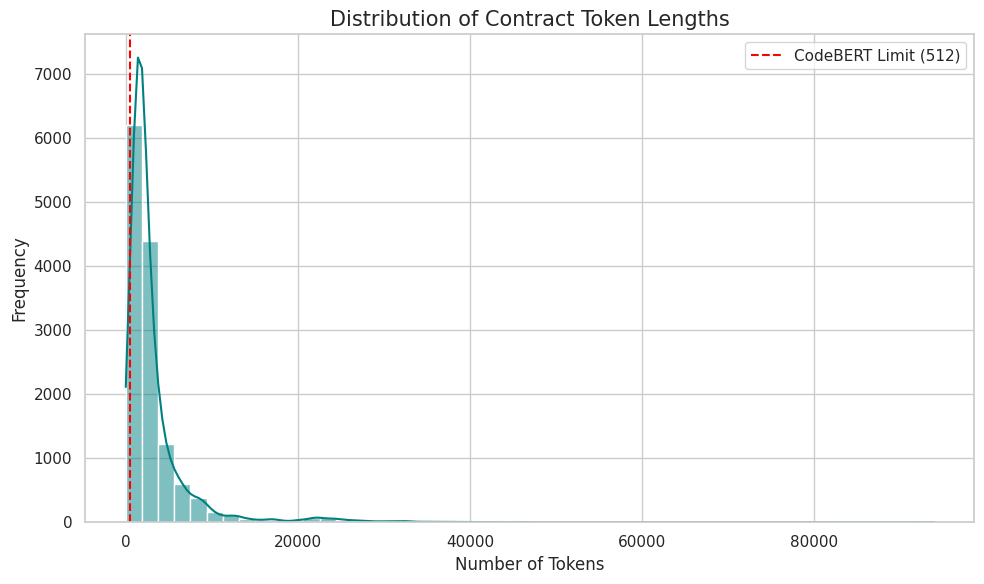

In [22]:
plt.figure(figsize=(10, 6))

# plot histogram of the token_len column you already created
sns.histplot(df_clean['token_len'], bins=50, kde=True, color='teal')

# draw a vertical line at the 512 mark
plt.axvline(x=512, color='red', linestyle='--', label='CodeBERT Limit (512)')

plt.title('Distribution of Contract Token Lengths', fontsize=15)
plt.xlabel('Number of Tokens', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()

# annotate the percentage of data over the limit
over_limit = (df_clean['token_len'] > 512).mean() * 100
print(over_limit)

plt.tight_layout()
plt.savefig('token_length_dist.png', dpi=300)
plt.show()

Split data


In [23]:
import ast
# Pre-parse the strings into Python lists once
df_clean['lines'] = df_clean['lines'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [24]:
# splitting:
from sklearn.model_selection import train_test_split
seed = 32
temp_df, test_df = train_test_split(
    df_clean,
    test_size=0.2,
    stratify=df_clean['is_vulnerable'],
    random_state=seed
)


train_df, val_df = train_test_split(
    temp_df,
    test_size=0.25,
    stratify=temp_df['is_vulnerable'],
    random_state=seed
)

In [25]:
train_vulnerable = train_df[train_df['is_vulnerable'] == True]
train_safe = train_df[train_df['is_vulnerable'] == False]

def custom_sample(group):
  # ignore minority class:
  if len(group) <= 500:
      return group

  frac = min(1.0, 3000 / len(group))
  return group.sample(frac=frac, random_state=seed)

# resample to balance
train_vulnerable_sampled = train_vulnerable.groupby('labels').apply(custom_sample).reset_index(drop=True)

# recombine
train_df_final = pd.concat([train_vulnerable_sampled, train_safe]).sample(frac=1, random_state=seed)

/tmp/ipykernel_70561/2945608028.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_vulnerable_sampled = train_vulnerable.groupby('labels').apply(custom_sample).reset_index(drop=True)


In [26]:
train_df_final["labels"].value_counts()
train_df["labels"].value_counts()

,count
labels,
arithmetic,4318
clean,1631
reentrancy,854
front_running,508
denial_service,457
unchecked_low_calls,179
access_control,85
time_manipulation,62


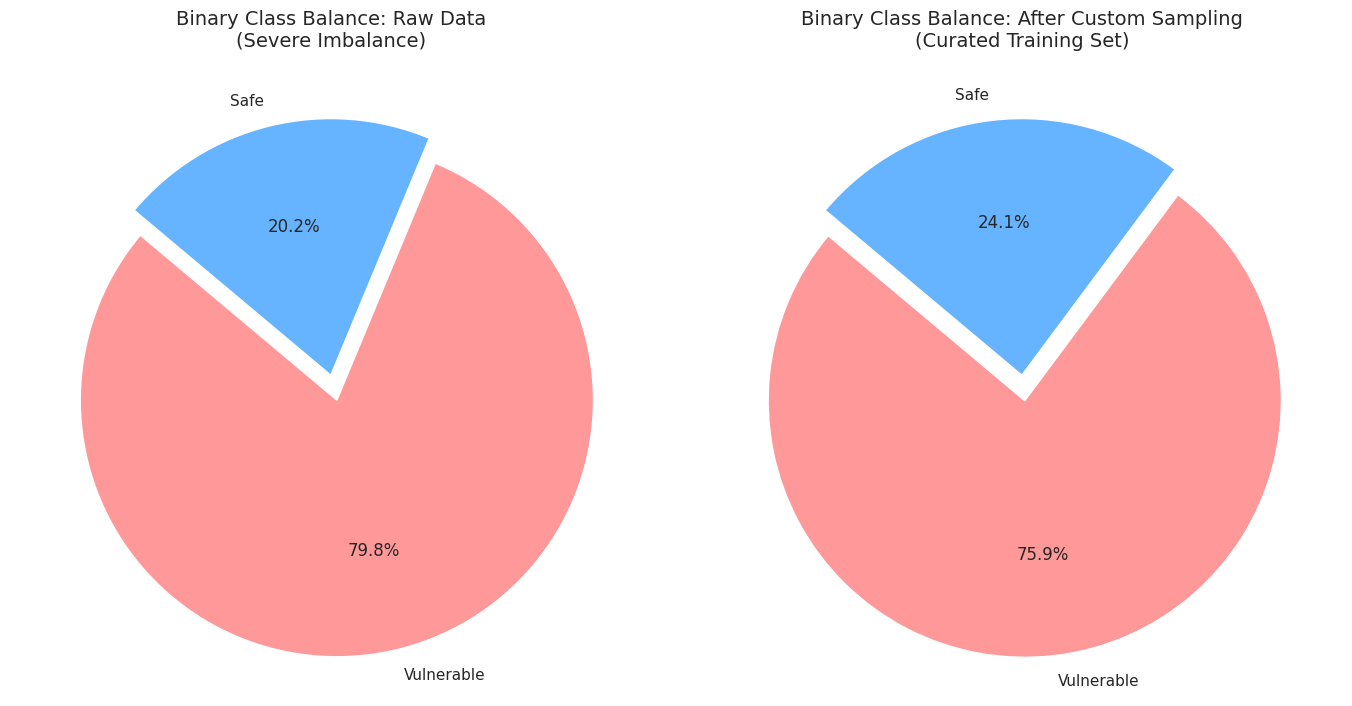

In [27]:
# show pie chart of the difference in distribution of samples before and after sampling
before_counts = df_clean['is_vulnerable'].value_counts()
after_counts = train_df_final['is_vulnerable'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Red == Vulnerable, Green == Safe
colors = ['#ff9999','#66b3ff']
labels = ['Vulnerable', 'Safe']

# before
ax1.pie(before_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0))
ax1.set_title('Binary Class Balance: Raw Data\n(Severe Imbalance)', fontsize=14)

# after
ax2.pie(after_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0))
ax2.set_title('Binary Class Balance: After Custom Sampling\n(Curated Training Set)', fontsize=14)

plt.tight_layout()
plt.savefig('imbalance_comparison.png', dpi=300)
plt.show()

## 5. Contract Chunking & Smart Sampling
To handle long contracts, we split them into chunks. During training, we use `smart_sample_contract` to ensure that for every vulnerable contract, at least one chunk containing the actual bug is included in the training batch.

In [28]:
print(f"Training: {train_df_final.shape}\n{train_df['is_vulnerable'].value_counts()}")
print(f"Validation: {val_df.shape}\n{val_df['is_vulnerable'].value_counts()}")
print(f"Test: {test_df.shape}\n{test_df['is_vulnerable'].value_counts()}")

Training: (6776, 10)
is_vulnerable
True     6463
False    1631
Name: count, dtype: int64
Validation: (2698, 10)
is_vulnerable
True     2154
False     544
Name: count, dtype: int64
Test: (2698, 10)
is_vulnerable
True     2154
False     544
Name: count, dtype: int64


# Contract Processing into Chunks:

In [29]:
mismatches = 0
import ast
for _, row in df_clean[df_clean['is_vulnerable'] == True].iterrows():
    source_lines = len(str(row['cleaned_contract']).split('\n'))
    vuln_lines = ast.literal_eval(row['lines']) if isinstance(row['lines'], str) else row['lines']

    if vuln_lines and isinstance(vuln_lines[0], list):
        vuln_lines = [item for sublist in vuln_lines for item in sublist]

    if any(l >= source_lines for l in vuln_lines):
        mismatches += 1

print(f"Contracts with suspicious label alignment: {mismatches}")

Contracts with suspicious label alignment: 1666


In [30]:
import random
def smart_sample_contract(chunks, vuln_indices, max_chunks=10, context_size=1):
    if len(chunks) <= max_chunks:
        return chunks

    selected_indices = set()

    # include vulnerable chunk if available
    if len(vuln_indices) > 0:
        chosen_vuln = random.choice(vuln_indices)
        selected_indices.add(chosen_vuln)

        # add local neighbors
        for offset in range(1, context_size + 1):
            if chosen_vuln - offset >= 0:
                selected_indices.add(chosen_vuln - offset)
            if chosen_vuln + offset < len(chunks):
                selected_indices.add(chosen_vuln + offset)

    remaining_pool = [i for i in range(len(chunks)) if i not in selected_indices]
    num_to_fill = max_chunks - len(selected_indices)

    if num_to_fill > 0:
        selected_indices.update(random.sample(
            remaining_pool,
            min(num_to_fill, len(remaining_pool))
        ))

    final_indices = sorted(selected_indices)

    if len(vuln_indices) > 0 and not any(i in final_indices for i in vuln_indices):
        final_indices.append(random.choice(vuln_indices))

    final_indices = sorted(final_indices)

    if len(final_indices) > max_chunks:
        # keep vuln + fill rest
        vuln_included = [i for i in final_indices if i in vuln_indices]
        others = [i for i in final_indices if i not in vuln_indices]

        final_indices = vuln_included[:1] + others[:max_chunks - 1]

    return [chunks[i] for i in final_indices]

In [31]:
def chunk_with_line_tracking(text, tokenizer, max_tokens=512, stride=5):
    """
    Line-first chunking (FIXED VERSION)
    - preserves exact line-to-label alignment
    - avoids token-level corruption
    """

    lines = text.split('\n')

    chunks = []
    current_lines = []
    current_line_indices = []

    def tokenize_lines(lines_subset):
        text = "\n".join(lines_subset)
        enc = tokenizer(
            text,
            add_special_tokens=True,
            truncation=False
        )
        return enc["input_ids"], enc["attention_mask"]

    i = 0
    while i < len(lines):
        current_lines = []
        current_line_indices = []

        j = i

        # build a chunk until token limit
        while j < len(lines):
            test_lines = current_lines + [lines[j]]
            input_ids, _ = tokenize_lines(test_lines)

            if len(input_ids) > max_tokens:
                break

            current_lines.append(lines[j])
            current_line_indices.append(j)
            j += 1

        # safety: avoid empty chunk
        if not current_lines:
            j += 1
            continue

        input_ids, attention_mask = tokenize_lines(current_lines)

        chunks.append({
            "input_ids": input_ids[:max_tokens],
            "attention_mask": attention_mask[:max_tokens],
            "line_indices": current_line_indices,
            "text": "\n".join(current_lines)
        })

        # stride (line-based overlap, NOT token-based)
        i = max(j - stride, i + 1)

    return chunks

In [32]:
def get_vulnerable_indices(chunks, vuln_lines):
    vuln_set = set(vuln_lines)

    vuln_indices = []
    for i, chunk in enumerate(chunks):
        if set(chunk["line_indices"]) & vuln_set:
            vuln_indices.append(i)

    return vuln_indices

In [33]:
import random
import ast

def process_data(df, tokenizer, augmentor=None, max_chunks=10, is_training=False):
    processed_data = []

    for row in df.itertuples(index=False):
        source = str(row.source_code)
        cleaned_source = clean_solidity_code_line_preserved(source)

        raw_lines = source.split("\n")
        cleaned_lines = cleaned_source.split("\n")

        source_line_count = len(raw_lines)

        # parse vulnerability labels
        raw_vuln_lines = row.lines

        if (
            raw_vuln_lines
            and isinstance(raw_vuln_lines, list)
            and isinstance(raw_vuln_lines[0], list)
        ):
            vuln_lines = list(set(
                x for sub in raw_vuln_lines for x in sub
            ))
        else:
            vuln_lines = (
                list(set(raw_vuln_lines))
                if isinstance(raw_vuln_lines, list)
                else []
            )

        vuln_lines = [
            int(v)
            for v in vuln_lines
            if isinstance(v, (int, float))
        ]

        # index
        if vuln_lines:
            if 0 in vuln_lines:
                # definitely already 0-indexed
                vuln_lines = [
                    v for v in vuln_lines
                    if 0 <= v < source_line_count
                ]
            else:
                # assume 1-indexed and convert to 0-indexed
                vuln_lines = [
                    v - 1 for v in vuln_lines
                    if 1 <= v <= source_line_count
                ]
        else:
            vuln_lines = []

        vuln_set = set(vuln_lines)

        line_token_lens = [
            len(
                tokenizer(
                    line,
                    add_special_tokens=False
                )["input_ids"]
            )
            for line in cleaned_lines
        ]


        chunks = []
        i = 0

        while i < len(cleaned_lines):

            current_lines = []
            current_indices = []
            current_len = 0

            j = i

            while j < len(cleaned_lines):

                # +1 approximates newline separator token
                next_len = line_token_lens[j] + 1

                if current_len + next_len > 512:
                    break

                current_lines.append(cleaned_lines[j])
                current_indices.append(j)  # line index preserved
                current_len += next_len
                j += 1

            # safety fallback for extremely long single lines
            if not current_lines:
                current_lines = [cleaned_lines[i]]
                current_indices = [i]
                j = i + 1

            chunks.append({
                "text": "\n".join(current_lines),
                "line_indices": current_indices
            })

            i = j

        if is_training:
            vuln_indices = [
                idx
                for idx, c in enumerate(chunks)
                if set(c["line_indices"]) & vuln_set
            ]

            final_chunks = []

            # always include vulnerable chunks first
            if vuln_indices:
              if len(vuln_indices) > max_chunks:
                  chosen = random.sample(vuln_indices, max_chunks)
                  final_chunks.extend([chunks[i] for i in chosen])
              else:
                  final_chunks.extend([chunks[i] for i in vuln_indices])

            # fill remaining slots with random negatives
            remaining = [
                i for i in range(len(chunks))
                if i not in vuln_indices
            ]

            random.shuffle(remaining)

            for i in remaining:
                if len(final_chunks) >= max_chunks:
                    break
                final_chunks.append(chunks[i])

            # emergency fallback
            if len(final_chunks) == 0 and len(chunks) > 0:
                final_chunks = [chunks[0]]
                print(
                    f"[WARNING] contract_id={row.contract_id} "
                    f"had no selected chunks"
                )

        else:
            final_chunks = chunks

        # dataset creation
        for chunk in final_chunks:

            chunk_lines = set(chunk["line_indices"])
            hit = chunk_lines & vuln_set

            ratio = len(hit) / max(len(chunk_lines), 1)

            label = 1 if hit else 0

            # weighted supervision: chose 0.1 after seeing distribution
            if ratio >= 0.1:
                weight = 2.0
            elif ratio > 0:
                weight = 1.5
            else:
                weight = 1.0

            chunk_line_labels = [
                1 if i in vuln_set else 0
                for i in chunk["line_indices"]
            ]

            enc = tokenizer(
                chunk["text"],
                max_length=512,
                padding="max_length",
                truncation=True
            )

            anchor_ids = enc["input_ids"]

            # contrastive positive pair augmentation
            if is_training and augmentor:
                aug_text = augmentor(chunk["text"])

                pos_ids = tokenizer(
                    aug_text,
                    max_length=512,
                    padding="max_length",
                    truncation=True
                )["input_ids"]
            else:
                pos_ids = anchor_ids

            processed_data.append({
                "contract_id": row.contract_id,
                "anchor_input_ids": anchor_ids,
                "pos_input_ids": pos_ids,
                "label": label,
                "weight": weight,
                "contract_label": int(row.is_vulnerable),
                "chunk_line_labels": chunk_line_labels
            })

    return processed_data

In [34]:
train_chunks_list = process_data(train_df_final, tokenizer, is_training = True)
val_chunks_list = process_data(val_df, tokenizer)
test_chunks_list = process_data(test_df, tokenizer)

Check whether the chunks were made correctly:

In [35]:
# Updated Consistency Check for flattened data
import pandas as pd

def verify_consistency(chunks_list, df_source, split_name="Train"):
    # Create a mapping of contract_id to its expected vulnerability status from the source DF
    expected_vuln = df_source[df_source['is_vulnerable'] == True]['contract_id'].unique()

    # Find which contract_ids in our processed list have at least one vulnerable chunk (label=1)
    actual_vuln_ids = {c['contract_id'] for c in chunks_list if c['label'] == 1}

    missing = [cid for cid in expected_vuln if cid in {c['contract_id'] for c in chunks_list} and cid not in actual_vuln_ids]

    print(f"--- {split_name} Consistency Report ---")
    print(f"Total Vulnerable Contracts in list: {len([cid for cid in expected_vuln if cid in {c['contract_id'] for c in chunks_list}])}")
    print(f"Contracts with at least one Vuln Chunk: {len(actual_vuln_ids)}")

    if not missing:
        print("SUCCESS: All vulnerable contracts have at least one positive chunk.")
    else:
        print(f"FAILED: {len(missing)} vulnerable contracts are missing a positive chunk.")
        print(f"Example missing ID: {missing[0]}")

verify_consistency(train_chunks_list, train_df_final, "Train")

--- Train Consistency Report ---
Total Vulnerable Contracts in list: 5145
Contracts with at least one Vuln Chunk: 5145
SUCCESS: All vulnerable contracts have at least one positive chunk.


/tmp/ipykernel_70561/1832983807.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=success_stats, x='labels', y='mapping_successful', palette='magma')


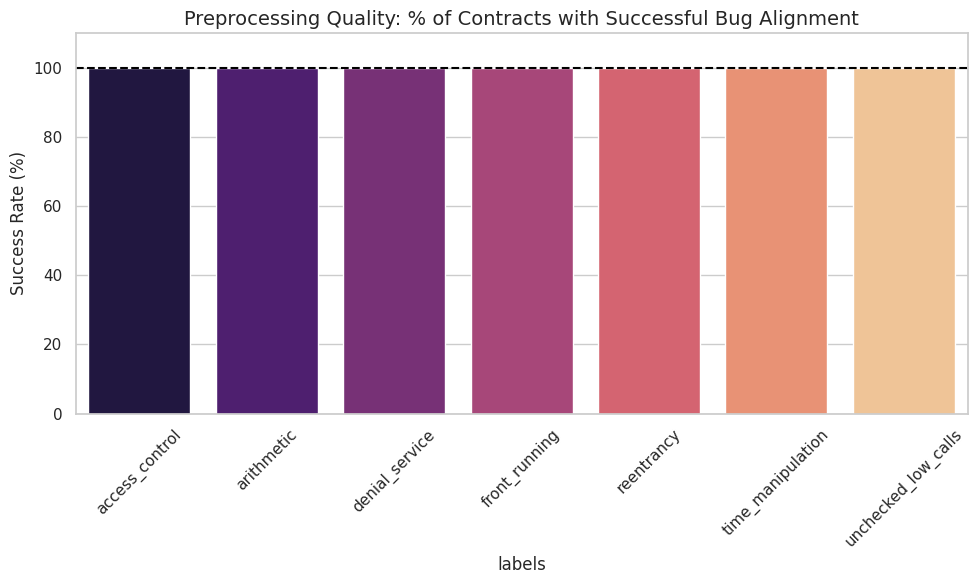

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_mapping_success(chunks_list, df_source):
    # Map which contract_ids have at least one positive chunk
    actual_vuln_ids = {c['contract_id'] for c in chunks_list if c['label'] == 1}

    # Filter source DF to only vulnerable contracts
    df_v = df_source[df_source['is_vulnerable'] == True].copy()
    df_v['mapping_successful'] = df_v['contract_id'].isin(actual_vuln_ids)

    # Calculate success rate per label
    success_stats = df_v.groupby('labels')['mapping_successful'].mean().reset_index()
    success_stats['mapping_successful'] *= 100  # Convert to percentage

    plt.figure(figsize=(10, 6))
    sns.barplot(data=success_stats, x='labels', y='mapping_successful', palette='magma')
    plt.axhline(100, color='black', linestyle='--')
    plt.title('Preprocessing Quality: % of Contracts with Successful Bug Alignment', fontsize=14)
    plt.ylabel('Success Rate (%)')
    plt.xticks(rotation=45)
    plt.ylim(0, 110)
    plt.tight_layout()
    plt.show()

plot_mapping_success(train_chunks_list, train_df_final)

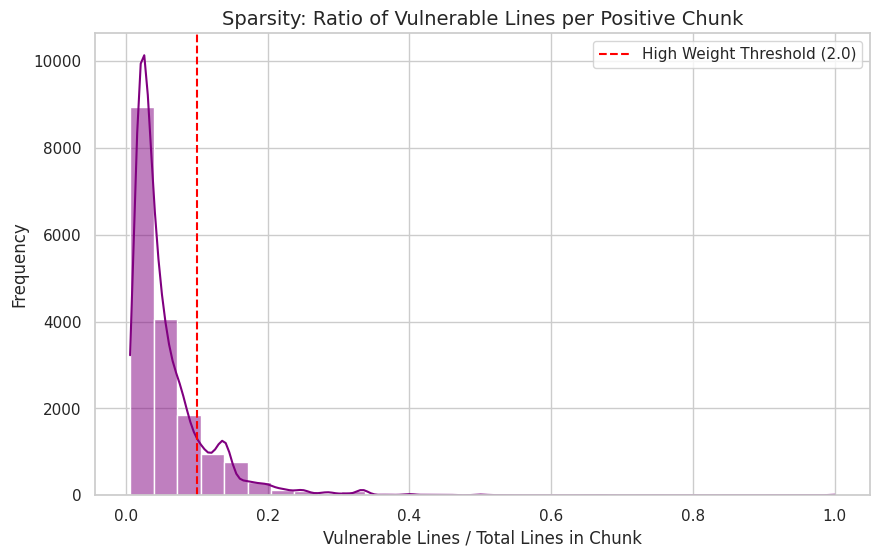

In [37]:
def plot_sparsity_distribution(chunks_list):
    # Calculate ratio of positive lines for all positive chunks
    ratios = [
        sum(c['chunk_line_labels']) / len(c['chunk_line_labels'])
        for c in chunks_list if c['label'] == 1
    ]

    plt.figure(figsize=(10, 6))
    sns.histplot(ratios, bins=30, kde=True, color='purple')

    # Annotate your current weight thresholds
    plt.axvline(0.1, color='red', linestyle='--', label='High Weight Threshold (2.0)')
    plt.title('Sparsity: Ratio of Vulnerable Lines per Positive Chunk', fontsize=14)
    plt.xlabel('Vulnerable Lines / Total Lines in Chunk')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

plot_sparsity_distribution(train_chunks_list)

/tmp/ipykernel_70561/3633023048.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=chunk_frequencies, palette='viridis')


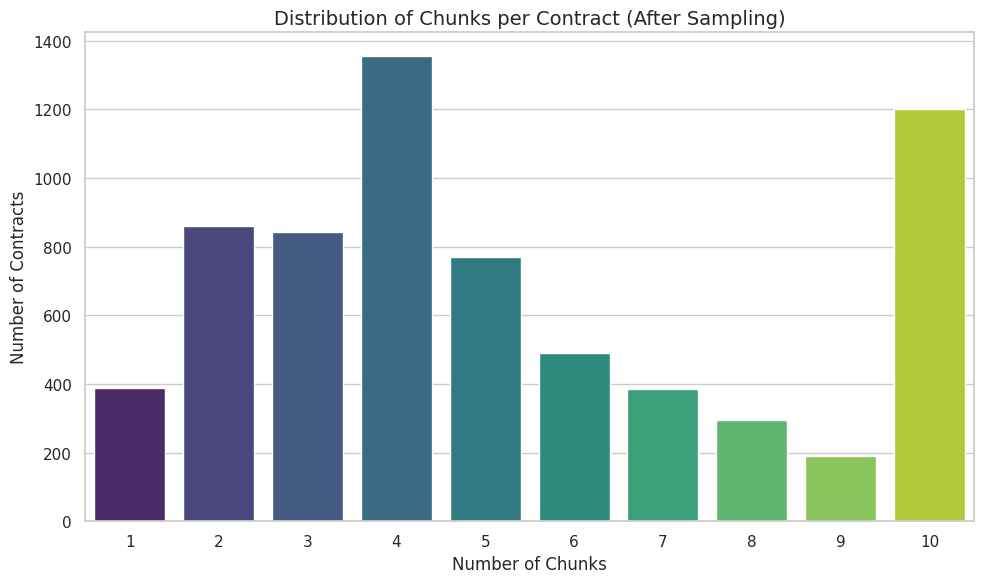

In [38]:
from collections import Counter

def plot_chunk_counts(chunks_list):
    # Count chunks per contract ID
    counts = Counter([c['contract_id'] for c in chunks_list])
    chunk_frequencies = list(counts.values())

    plt.figure(figsize=(10, 6))
    sns.countplot(x=chunk_frequencies, palette='viridis')
    plt.title('Distribution of Chunks per Contract (After Sampling)', fontsize=14)
    plt.xlabel('Number of Chunks')
    plt.ylabel('Number of Contracts')
    plt.tight_layout()
    plt.show()

plot_chunk_counts(train_chunks_list)

--- Mean Vulnerability Density per Class ---
              Category   Density
0           reentrancy  0.066693
1    time_manipulation  0.064830
2           arithmetic  0.059502
3       denial_service  0.053158
4  unchecked_low_calls  0.051835
5       access_control  0.048347
6        front_running  0.046533


/tmp/ipykernel_70561/4133601846.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Density', y='Category', data=class_means, palette='viridis')


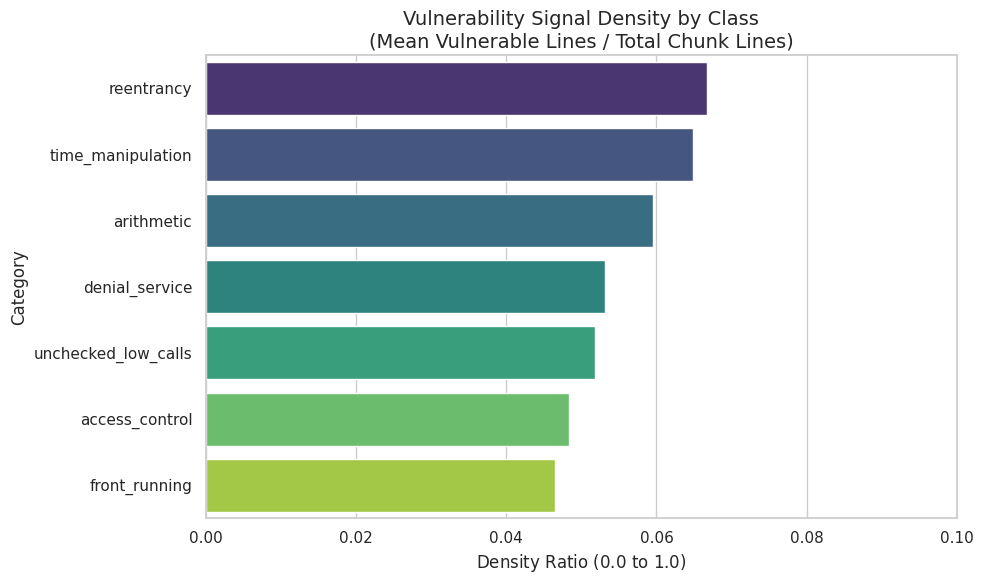

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def log_class_density(chunks_list, df_source):
    # 1. Create lookup for contract categories
    id_to_label = df_source.set_index('contract_id')['labels'].to_dict()

    # 2. Extract ratios for all positive chunks
    records = []
    for chunk in chunks_list:
        if chunk['label'] == 1:  # Only look at chunks containing a vulnerability
            cat = id_to_label.get(chunk['contract_id'], "Unknown")

            num_vuln = sum(chunk['chunk_line_labels'])
            total_ln = len(chunk['chunk_line_labels'])
            ratio = num_vuln / max(total_ln, 1)

            records.append({'Category': cat, 'Density': ratio})

    # 3. Aggregate results
    density_df = pd.DataFrame(records)
    class_means = density_df.groupby('Category')['Density'].mean().sort_values(ascending=False).reset_index()

    print("--- Mean Vulnerability Density per Class ---")
    print(class_means)


    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    ax = sns.barplot(x='Density', y='Category', data=class_means, palette='viridis')

    plt.title('Vulnerability Signal Density by Class\n(Mean Vulnerable Lines / Total Chunk Lines)', fontsize=14)
    plt.xlabel('Density Ratio ($0.0$ to $1.0$)', fontsize=12)
    plt.xlim(0, 0.1) # Zoom in to show the differences clearly
    plt.tight_layout()
    plt.savefig('final_density_results.png', dpi=300)

# Run the analysis
log_class_density(train_chunks_list, df_clean)

In [40]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_chunk_distribution(chunks_list, split_name="Train"):
    # Extract labels and contract IDs from the chunk dictionaries
    labels = [c['label'] for c in chunks_list]
    contract_ids = [c['contract_id'] for c in chunks_list]

    counts = Counter(labels)
    total_chunks = len(labels)
    unique_contracts = len(set(contract_ids))

    print(f"--- {split_name} Set Analysis ---")
    print(f"Total Chunks generated: {total_chunks}")
    print(f"Total Unique Contracts represented: {unique_contracts}")
    print(f"Average chunks per contract: {total_chunks/unique_contracts:.2f}")

    for label, count in counts.items():
        label_name = "Vulnerable (1)" if label == 1 else "Safe (0)"
        percentage = (count / total_chunks) * 100
        print(f"  - {label_name}: {count} chunks ({percentage:.2f}%)")
    print("\n" + "="*40 + "\n")

# Execute verification for all splits
analyze_chunk_distribution(train_chunks_list, "Training")
analyze_chunk_distribution(val_chunks_list, "Validation")
analyze_chunk_distribution(test_chunks_list, "Test")

--- Training Set Analysis ---
Total Chunks generated: 35612
Total Unique Contracts represented: 6776
Average chunks per contract: 5.26
  - Vulnerable (1): 17293 chunks (48.56%)
  - Safe (0): 18319 chunks (51.44%)


--- Validation Set Analysis ---
Total Chunks generated: 19186
Total Unique Contracts represented: 2698
Average chunks per contract: 7.11
  - Safe (0): 11046 chunks (57.57%)
  - Vulnerable (1): 8140 chunks (42.43%)


--- Test Set Analysis ---
Total Chunks generated: 19422
Total Unique Contracts represented: 2698
Average chunks per contract: 7.20
  - Vulnerable (1): 8081 chunks (41.61%)
  - Safe (0): 11341 chunks (58.39%)




In [41]:
def inspect_random_contract(df_source, chunks_list, n_examples=3):
    import random

    contract_ids = list(set(c["contract_id"] for c in chunks_list))
    sampled_ids = random.sample(contract_ids, min(n_examples, len(contract_ids)))

    for cid in sampled_ids:
        print("\n" + "=" * 80)
        print(f"CONTRACT ID: {cid}")
        print("=" * 80)

        # original row
        row = df_source[df_source["contract_id"] == cid].iloc[0]

        print("\n--- Contract-level info ---")
        print("is_vulnerable:", row["is_vulnerable"])
        print("label type:", row["labels"])
        print("raw vuln lines:", row["lines"])

        source_lines = str(row["source_code"]).split("\n")

        # all chunks for this contract
        contract_chunks = [
            c for c in chunks_list
            if c["contract_id"] == cid
        ]

        print(f"\nTotal chunks: {len(contract_chunks)}")

        for idx, chunk in enumerate(contract_chunks):
            print("\n" + "-" * 60)
            print(f"CHUNK {idx}")
            print("-" * 60)

            print("Chunk label:", chunk["label"])
            print("Contract label:", chunk["contract_label"])
            print("Weight:", chunk["weight"])

            # reconstruct approximate line span
            line_labels = chunk["chunk_line_labels"]
            num_lines = len(line_labels)

            print("Chunk num lines:", num_lines)
            print("Positive line labels:", sum(line_labels))

            print("\nchunk_line_labels:")
            print(line_labels[:80])

            print("\nDecoded text preview:")

            decoded = tokenizer.decode(
                chunk["anchor_input_ids"],
                skip_special_tokens=True
            )

            print(decoded[:1500])  # preview only
            print("\n")

inspect_random_contract(train_df_final, train_chunks_list, n_examples=5)


CONTRACT ID: 3504

--- Contract-level info ---
is_vulnerable: True
label type: access_control
raw vuln lines: [2, 867, 898]

Total chunks: 3

------------------------------------------------------------
CHUNK 0
------------------------------------------------------------
Chunk label: 1
Contract label: 1
Weight: 1.5
Chunk num lines: 46
Positive line labels: 1

chunk_line_labels:
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Decoded text preview:
 



interface tokenRecipient { function receiveApproval(address _from, uint256 _value, address _token, bytes calldata _extraData) external; }

contract ContractTokenERC20 {
     
    string public name;
    string public symbol;
    uint8 public decimals = 18;
     
    uint256 public totalSupply;

     
    mapping (address => uint256) public balanceOf;

     
    event Transfer(address indexed from, address indexed to, uint256 value);

    




    

In [44]:
from collections import defaultdict

def validate_processed_data(processed_data):
    stats = {
        "total_chunks": 0,
        "positive_chunks": 0,
        "negative_chunks": 0,
        "label_mismatch": 0,
        "weight_mismatch": 0,
        "clean_contract_with_positive_chunk": 0,
        "vuln_contract_missing_positive_chunk": 0,
    }

    contract_summary = defaultdict(lambda: {
        "contract_label": None,
        "has_positive_chunk": False
    })

    bad_examples = []

    for chunk in processed_data:
        stats["total_chunks"] += 1

        contract_id = chunk["contract_id"]
        contract_label = chunk["contract_label"]
        label = chunk["label"]
        weight = chunk["weight"]
        line_labels = chunk["chunk_line_labels"]

        positives = sum(line_labels)
        positive_ratio = positives / max(len(line_labels), 1)
        # label check
        expected_label = 1 if positives > 0 else 0

        if label != expected_label:
            stats["label_mismatch"] += 1
            bad_examples.append({
                "contract_id": contract_id,
                "issue": f"label mismatch: expected {expected_label}, got {label}"
            })
        # weight check
        if positive_ratio >= 0.1:
            expected_weight = 2.0
        elif positive_ratio > 0:
            expected_weight = 1.5
        else:
            expected_weight = 1.0

        if weight != expected_weight:
            stats["weight_mismatch"] += 1
            bad_examples.append({
                "contract_id": contract_id,
                "issue": f"weight mismatch: expected {expected_weight}, got {weight}"
            })
        # stats
        if label == 1:
            stats["positive_chunks"] += 1
            contract_summary[contract_id]["has_positive_chunk"] = True
        else:
            stats["negative_chunks"] += 1

        contract_summary[contract_id]["contract_label"] = contract_label

    # contract-level validation
    for contract_id, info in contract_summary.items():
        contract_label = info["contract_label"]
        has_positive_chunk = info["has_positive_chunk"]

        if contract_label == 0 and has_positive_chunk:
            stats["clean_contract_with_positive_chunk"] += 1
            bad_examples.append({
                "contract_id": contract_id,
                "issue": "clean contract has positive chunk"
            })

        if contract_label == 1 and not has_positive_chunk:
            stats["vuln_contract_missing_positive_chunk"] += 1
            bad_examples.append({
                "contract_id": contract_id,
                "issue": "vulnerable contract missing positive chunk"
            })

    return stats, bad_examples
stats, bad = validate_processed_data(train_chunks_list)

print(stats)

print("\nBad examples:")
for x in bad[:20]:
    print(x)

{'total_chunks': 35612, 'positive_chunks': 17293, 'negative_chunks': 18319, 'label_mismatch': 0, 'weight_mismatch': 0, 'clean_contract_with_positive_chunk': 0, 'vuln_contract_missing_positive_chunk': 0}

Bad examples:


## 6. Final Export
The processed data is saved as PyTorch tensors (`.pt`) containing input IDs, attention masks, and chunk-level labels for use in the model training notebook.

In [43]:
import torch
TARGET_DIR = '/content/drive/My Drive/CPSC440_project/data/'
torch.save(train_chunks_list, TARGET_DIR+"train_chunks.pt")
torch.save(val_chunks_list, TARGET_DIR+"val_chunks.pt")
torch.save(test_chunks_list, TARGET_DIR+"test_chunks.pt")